In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


%matplotlib inline 


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

print ("All Imports Successful")

All Imports Successful


In [2]:
df = pd.read_csv(
    "/Users/chetanm/Documents/Credit_Risk_Scorecard/data/raw/accepted_2007_to_2018Q4.csv.gz",
    compression = "gzip" , 
    low_memory =False 
)


print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (2260701, 151)
Rows: 2,260,701
Columns: 151


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.dtypes.value_counts()

float64    113
object      38
Name: count, dtype: int64

In [5]:
print(df["loan_status"].value_counts())
print()
print(df["loan_status"].value_counts(normalize=True).round(3)*100)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

loan_status
Fully Paid                                             47.6
Current                                                38.9
Charged Off                                            11.9
Late (31-120 days)                                      0.9
In Grace Period                                         0.4
Late (16-30 days)                                       0.2
Does not meet the cred

In [6]:
# as seen from above there are a variety of type of loans included int he dataset , 
# we primarily jsut need the Fully Paid , Charged Off and Defaulted loans , while we filter out the others 

keep_status = ["Fully Paid", "Charged Off" , "Default"]
df = df[df["loan_status"].isin(keep_status)]

# create a sort of binary indicator of good(0) or bad(1) loans 
df["target"]  = (df["loan_status"].isin(["Charged Off", "Default"])).astype(int)

#runnign a verification 
print(f"Shape after fitlering: (df.shape)")
print()
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3)*100)

Shape after fitlering: (df.shape)

target
0    1076751
1     268599
Name: count, dtype: int64

target
0    80.0
1    20.0
Name: proportion, dtype: float64


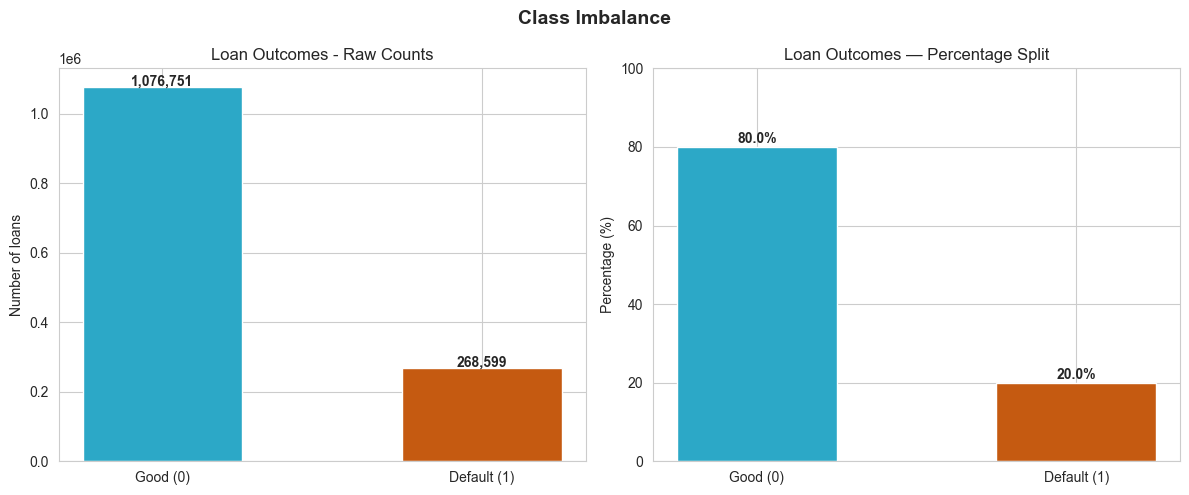

In [9]:
# trying to plot the imbalance 

fig, axes = plt.subplots(1,2, figsize = (12,5))

# left plot -> raw counts 
counts = df["target"].value_counts()
axes[0].bar(["Good (0)" , "Default (1)"], counts.values, color=["#2CA8C7","#C55A11"], width=0.5)
axes[0].set_title("Loan Outcomes - Raw Counts")
axes[0].set_ylabel("Number of loans")
for i,v in enumerate(counts.values):
    axes[0].text(i,v+5000,f"{v:,}", ha="center" , fontweight="bold")


# right plot - percentages 
percentages = df["target"].value_counts(normalize=True)*100
axes[1].bar(["Good (0)" , "Default (1)"], percentages.values, color=["#2CA8C7","#C55A11"],width=0.5)
axes[1].set_title("Loan Outcomes — Percentage Split")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)


for i, v in enumerate(percentages.values): 
    axes[1].text(i,v+1,f"{v:.1f}%",ha="center", fontweight="bold")

plt.suptitle("Class Imbalance", fontsize=14 , fontweight="bold")
plt.tight_layout() 
plt.show()

In [10]:
missing = (df.isnull().sum() / len(df)*100).sort_values(ascending=False)
missing = missing[missing>0]

print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}")
print()
print(missing.head(20))

Columns with missing values: 105 out of 152

member_id                                     100.000000
next_pymnt_d                                   99.997027
orig_projected_additional_accrued_interest     99.720444
hardship_type                                  99.572156
hardship_reason                                99.572156
hardship_status                                99.572156
deferral_term                                  99.572156
hardship_amount                                99.572156
hardship_start_date                            99.572156
payment_plan_start_date                        99.572156
hardship_length                                99.572156
hardship_dpd                                   99.572156
hardship_loan_status                           99.572156
hardship_end_date                              99.572156
hardship_payoff_balance_amount                 99.572156
hardship_last_payment_amount                   99.572156
sec_app_mths_since_last_major_derog        

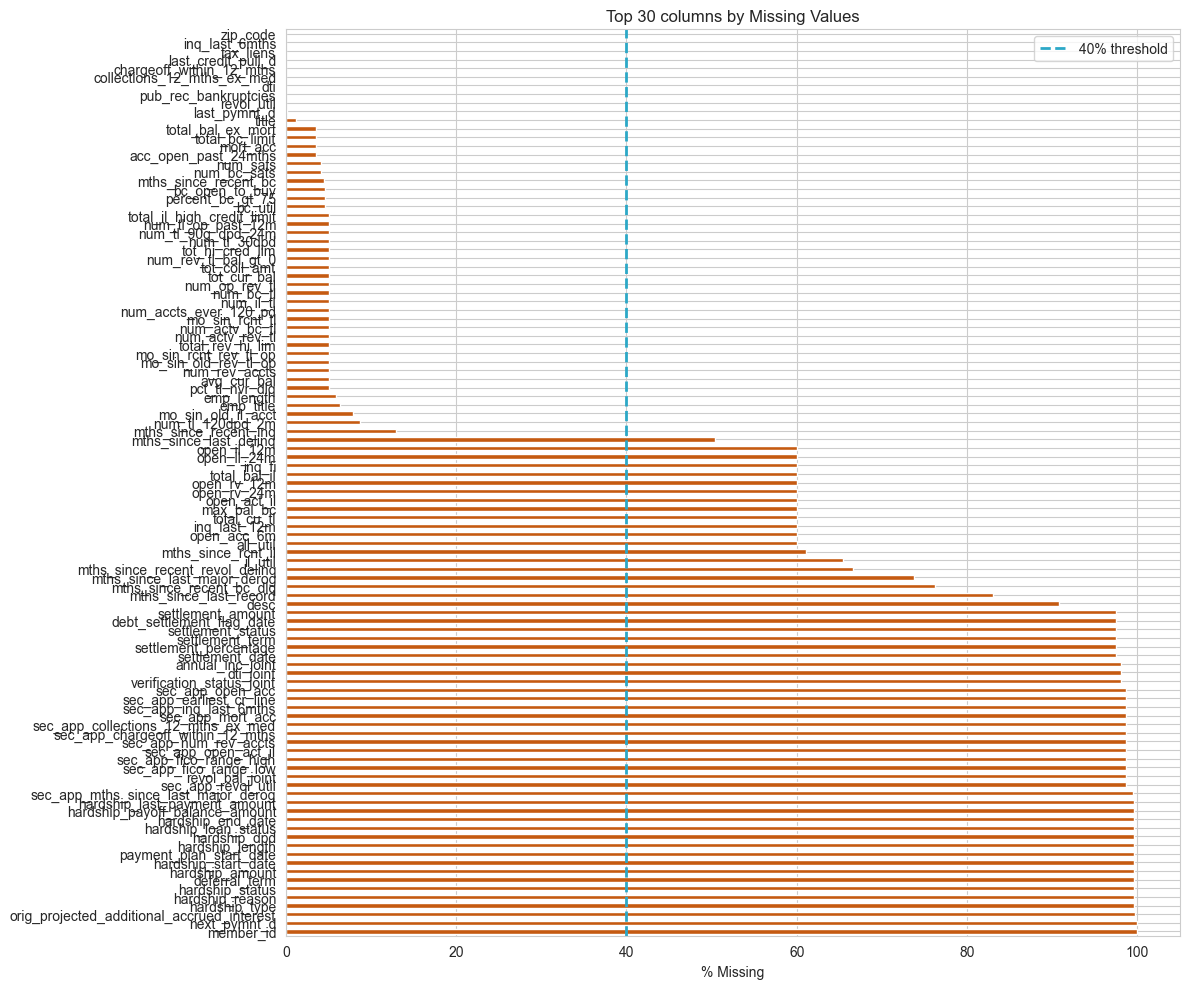

In [17]:
plt.figure(figsize=(12,10))
missing.head(300).plot(kind="barh", color="#C55A11")
plt.xlabel("% Missing")
plt.title("Top 30 columns by Missing Values")
plt.axvline(x=40, color="#2CA8C7", linestyle="--", linewidth = 2 , label = "40% threshold")
plt.legend() 
plt.tight_layout() 
plt.show()

In [19]:
# soemthing i noticed and would like to keep in mind going forward , often dataset are filled with sparsely populated variables , 
# which upon feeding into a model and training upon that would essentially be training it on noise , or very specifc cases which is bad imo 
# so food for thought going forward 

In [20]:
# dropping teh columns with more than 40 percent 
cols_to_drop = missing[missing > 40].index.tolist()

print(f"Columns to drop (>40% missing): {len(cols_to_drop)}")
print()
print(cols_to_drop)

df = df.drop(columns = cols_to_drop)

print()
print(f"Shape after dropping high missing value columns : {df.shape}")

Columns to drop (>40% missing): 58

['member_id', 'next_pymnt_d', 'orig_projected_additional_accrued_interest', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'hardship_end_date', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mort_acc', 'sec_app_inq_last_6mths', 'sec_app_earliest_cr_line', 'sec_app_open_acc', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'settlement_date', 'settlement_percentage', 'settlement_term', 'settlement_status', 'debt_settlement_flag_date', 'settlement_amount', 'desc', 'mths_since_last_record', 'mths_since_recent_bc_

In [23]:
# now i'll remove those columns which hood info that the model will not have at time fo decisioning (basically to prevent  the mdoel from cheating :) , this is what is termed as data leakage)

In [25]:
leakage_cols = [
    "recoveries" , 
    "collection_recovery_fee",
    "last_pymnt_amnt",
    "last_pymnt_d",
    "last_credit_pull_d",
    "last_fico_range_high",
    "last_fico_range_low",
    "loan_status"
]


leakage_cols = [col for col in leakage_cols if col in df.columns] 
print(leakage_cols)

df = df.drop(columns = leakage_cols)

print(f"Dropped {len(leakage_cols)} leakage columns")
print(f"Shape after dropping leakage columns : {df.shape}")


['recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'loan_status']
Dropped 8 leakage columns
Shape after dropping leakage columns : (1345350, 86)


In [26]:
df.to_csv("../data/processed/df_cleaned.csv", index=False)
print("Saved to data/processed/df_cleaned.csv")
print(f"Shape: {df.shape}")

Saved to data/processed/df_cleaned.csv
Shape: (1345350, 86)


In [57]:
#use this to reload data from teh checkpoint

df = pd.read_csv("../data/processed/df_cleaned.csv", low_memory=False)
print(f"Shape: {df.shape}")

Shape: (1345350, 86)


In [51]:
# plotting specific featyures , which are most important from a high elvel view 

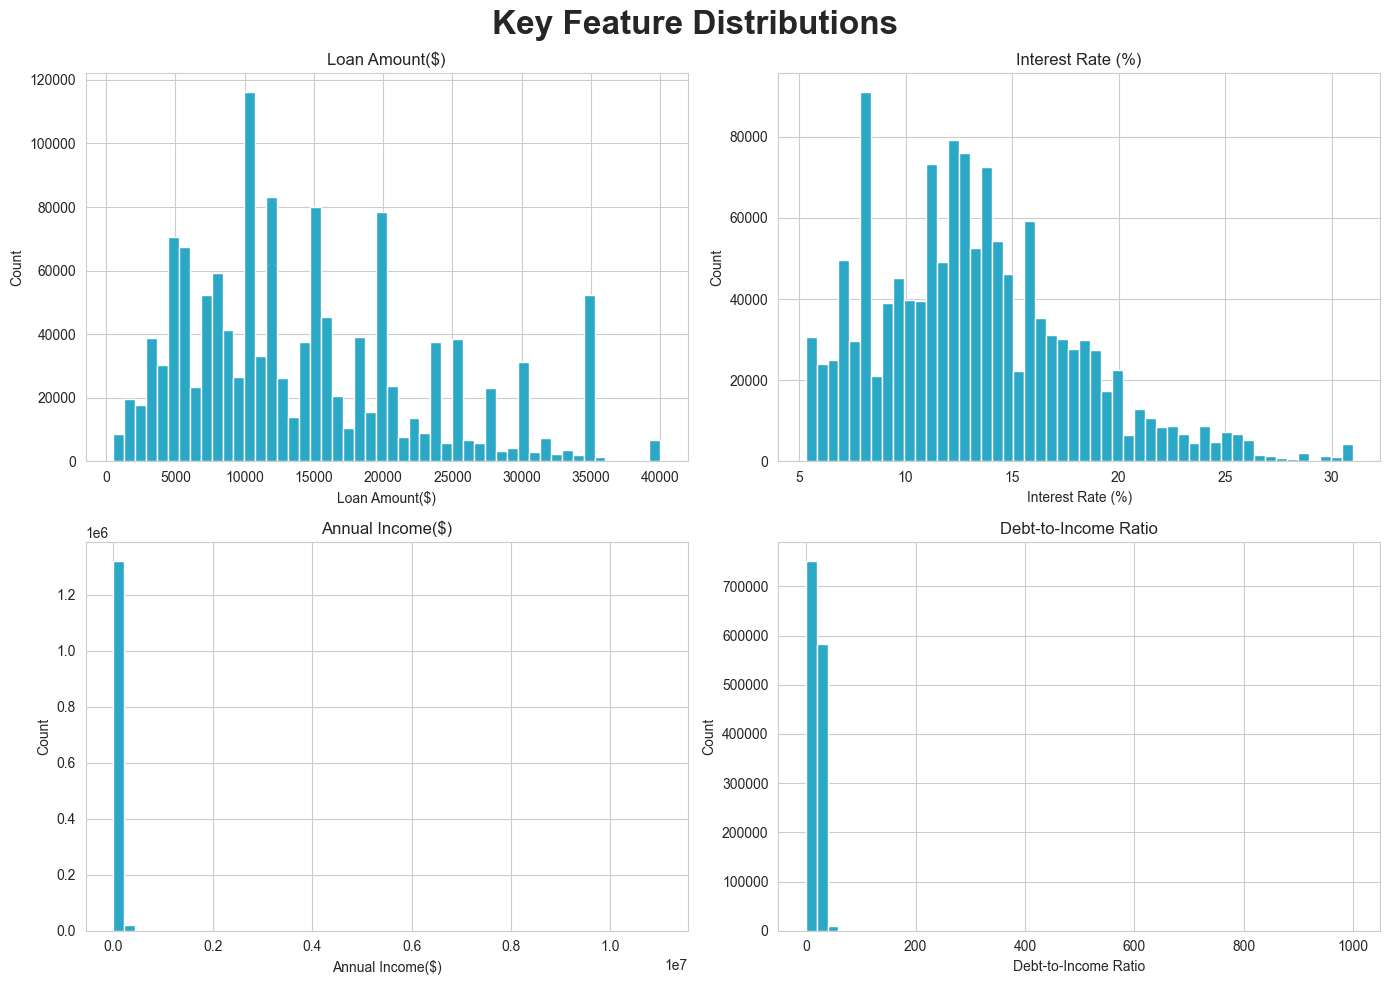

In [58]:
fig, axes = plt.subplots(2,2, figsize =(14,10))

features = {
    "loan_amnt": "Loan Amount($)",
    "int_rate": "Interest Rate (%)",
    "annual_inc": "Annual Income($)" , 
    "dti": "Debt-to-Income Ratio"
}

for ax, (col,label) in zip(axes.flatten(), features.items()): 
        df[col].hist(bins=50, ax=ax, color="#2CA8C7", edgecolor="white")
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel("Count")

plt.suptitle("Key Feature Distributions" , fontsize=24 , fontweight="bold")
plt.tight_layout()
plt.show()

In [59]:
print("Annual Income stats:")
print(df["annual_inc"].describe())
print()
print("DTI stats:")
print(df["dti"].describe())

Annual Income stats:
count    1.345350e+06
mean     7.624757e+04
std      6.992485e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

DTI stats:
count    1.344976e+06
mean     1.828264e+01
std      1.116041e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64


In [60]:
print("Annual Income 99.99th percentile:", df["annual_inc"].quantile(0.9999))
print("DTI 99th percentile:", df["dti"].quantile(0.99))
print("DTI 99.5th percentile:", df["dti"].quantile(0.995))
print("DTI 99.9th percentile:", df["dti"].quantile(0.999))
print()
print("Annual Income 95th percentile:", df["annual_inc"].quantile(0.95))
print("DTI 95th percentile:", df["dti"].quantile(0.95))
print()
print("Rows above annual_inc 99th percentile:", (df["annual_inc"] > df["annual_inc"].quantile(0.99)).sum())
print("Rows above dti 99th percentile:", (df["dti"] > df["dti"].quantile(0.99)).sum())
print("Rows with dti < 0:", (df["dti"] < 0).sum())

Annual Income 99.99th percentile: 1500000.0
DTI 99th percentile: 38.47
DTI 99.5th percentile: 40.07125
DTI 99.9th percentile: 66.08050000000279

Annual Income 95th percentile: 155000.0
DTI 95th percentile: 32.99

Rows above annual_inc 99th percentile: 13448
Rows above dti 99th percentile: 13446
Rows with dti < 0: 2


In [61]:
# Dropping Outliers

inc_threshold = df["annual_inc"].quantile(0.999)
dti_threshold = df["dti"].quantile(0.999)

print(f"Annual Income Threshold : ${inc_threshold:,.0f}")
print(f"DTI Threshold: {dti_threshold:.2f}")

initial_rows = len(df)

df = df[
    (df["annual_inc"] <= inc_threshold) &
    (df["annual_inc"] > 0) &
    (df["dti"] <= dti_threshold) &
    (df["dti"] >= 0)
]

dropped = initial_rows - len(df)
print(f"\nRows dropped: {dropped:,}")
print(f"Rows remaining: {len(df):,}")
print(f"% dropped: {dropped/initial_rows*100:.2f}%")


Annual Income Threshold : $577,302
DTI Threshold: 66.08

Rows dropped: 3,067
Rows remaining: 1,342,283
% dropped: 0.23%


In [62]:
df.to_csv("../data/processed/df_cleaned_2.csv", index=False)
print("Checkpoint updated")
print(f"Final shape: {df.shape}")

Checkpoint updated
Final shape: (1342283, 86)


In [66]:
# splitting the training and test dataset : theory behind that 
# A random split doesn't test this at all. If you randomly mix 2016–2020 data, 
# your test set contains loans from the same economic environment as your training set. 
# The model looks great on paper but you have no idea if it actually generalises to new conditions.
# An out-of-time split — train on 2016–2018, test on 2019–2020 — genuinely simulates deployment. 
# The model has never seen 2019–2020 data during training. 
# If it performs well on that test set, you have real confidence it will work in production.

In [67]:
print(df["issue_d"].dtype)
print(df["issue_d"].value_counts().sort_index().head(10))

object
issue_d
Apr-2008      155
Apr-2009      290
Apr-2010      825
Apr-2011     1563
Apr-2012     3227
Apr-2013     9411
Apr-2014    18162
Apr-2015    31767
Apr-2016    24060
Apr-2017    13035
Name: count, dtype: int64


In [73]:
# Convert to datetime
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")

# Check the range
print("Earliest loan:", df["issue_d"].min())
print("Latest loan:", df["issue_d"].max())
print()
print("Loans by year:")
print(df["issue_d"].dt.year.value_counts().sort_index())

Earliest loan: 2007-06-01 00:00:00
Latest loan: 2018-12-01 00:00:00

Loans by year:
issue_d
2007       250
2008      1561
2009      4703
2010     11509
2011     21710
2012     53333
2013    134728
2014    222944
2015    375140
2016    292547
2017    168218
2018     55640
Name: count, dtype: int64


In [75]:
train = df[df["issue_d"].dt.year.between(2010,2015)]
test = df[df["issue_d"].dt.year.between(2016,2018)]


print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print()
print(f"Train years: {train['issue_d'].dt.year.min()} - {train['issue_d'].dt.year.max()}")
print(f"Test years: {test['issue_d'].dt.year.min()} - {test['issue_d'].dt.year.max()}")
print()
print("Train target distribution:")
print(train["target"].value_counts(normalize=True).round(3)*100)
print()
print("Test target distribution:")
print(test["target"].value_counts(normalize=True).round(3)*100)

Train shape: (819364, 87)
Test shape: (516405, 87)

Train years: 2010 - 2015
Test years: 2016 - 2018

Train target distribution:
target
0    81.5
1    18.5
Name: proportion, dtype: float64

Test target distribution:
target
0    77.6
1    22.4
Name: proportion, dtype: float64


In [76]:
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

print("Train saved: data/processed/train.csv")
print("Test saved: data/processed/test.csv")
print()
print(f"Train: {train.shape[0]:,} rows")
print(f"Test: {test.shape[0]:,} rows")
print()
print("IMPORTANT: Test set is now locked.")
print("Do not touch it again until Phase 4 validation.")

Train saved: data/processed/train.csv
Test saved: data/processed/test.csv

Train: 819,364 rows
Test: 516,405 rows

IMPORTANT: Test set is now locked.
Do not touch it again until Phase 4 validation.


In [1]:
import statsmodels.api as sm
print(sm.__version__)

0.14.6
